**To develop a linear regression model for predicting the aqueous solubility (logS) of drug molecules using physicochemical descriptors.** or **Drug Solubility Prediction Using a Supervised Linear Regression Model**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/pharma_solubility_data.xlsx"

df = pd.read_excel(url)

df.head()

,molecular_weight,logP,num_h_donors,num_h_acceptors,polar_surface_area,num_rotatable_bonds,logS
0,339.74,1.257,2,2,75.76,4,-7.386
1,288.94,1.660,3,5,17.41,3,-5.284
2,351.82,3.621,1,6,74.58,5,-8.281
3,421.84,3.416,3,3,54.31,4,-9.706
4,281.27,2.469,2,1,60.21,4,-6.969


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

(300, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   molecular_weight     300 non-null    float64
 1   logP                 300 non-null    float64
 2   num_h_donors         300 non-null    int64  
 3   num_h_acceptors      300 non-null    int64  
 4   polar_surface_area   300 non-null    float64
 5   num_rotatable_bonds  300 non-null    int64  
 6   logS                 300 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 16.5 KB
None
       molecular_weight        logP  num_h_donors  num_h_acceptors  \
count        300.000000  300.000000    300.000000       300.000000   
mean         299.559667    2.467373      2.000000         3.953333   
std           78.528008    1.441160      1.351328         1.997780   
min           50.000000   -1.207000      0.000000         0.000000   
25%          245.342500    1.44

In [ ]:
X = df.drop(columns=["logS"])

y = df["logS"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

print("\nIntercept =", model.intercept_)

               Feature  Coefficient
0     molecular_weight    -0.020396
1                 logP    -0.607264
2         num_h_donors     0.128482
3      num_h_acceptors     0.108256
4   polar_surface_area    -0.010540
5  num_rotatable_bonds    -0.013437

Intercept = 0.7535058424218262


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
results = pd.DataFrame({
    "Actual logS": y_test.values,
    "Predicted logS": y_pred
})

results.head(10)

,Actual logS,Predicted logS
0,-9.637,-9.530627
1,-7.745,-7.943200
2,-5.269,-5.513908
3,-7.200,-7.663857
4,-5.159,-4.853060
5,-4.950,-5.188042
6,-5.398,-4.661673
7,-7.077,-7.465173
8,-7.002,-7.056239
9,-7.591,-8.130552


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,3))

print("Mean Squared Error :", round(mse,3))

print("Root Mean Squared Error :", round(rmse,3))

print("R² Score :", round(r2,3))

Mean Absolute Error : 0.414
Mean Squared Error : 0.249
Root Mean Squared Error : 0.499
R² Score : 0.906


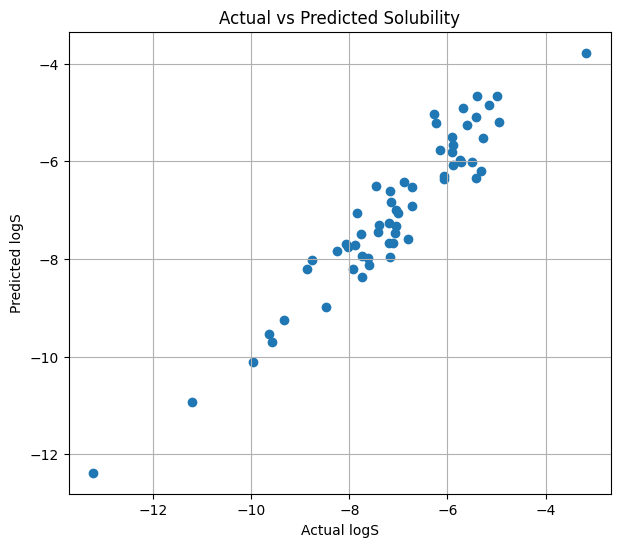

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual logS")

plt.ylabel("Predicted logS")

plt.title("Actual vs Predicted Solubility")

plt.grid(True)

plt.show()

In [ ]:
new_drug = pd.DataFrame({

    "molecular_weight":[350],

    "logP":[2.8],

    "num_h_donors":[2],

    "num_h_acceptors":[5],

    "polar_surface_area":[78],

    "num_rotatable_bonds":[4]

})

prediction = model.predict(new_drug)

print("Predicted logS =", prediction[0])

Predicted logS = -8.163004135050297


**Step 1: Import Required Libraries**

In this step, we import the Python libraries required for the experiment. These libraries provide functions for data handling, machine learning, model evaluation, and data visualization.

**Step 2: Load the Dataset from GitHub**

In this step, we load the pharmaceutical solubility dataset stored in the GitHub repository into a Pandas DataFrame. This dataset will be used for developing and evaluating the regression model.

**Step 3: View Dataset Information**

In this step, we explore the dataset by checking its dimensions, data types, summary statistics, and overall structure. Understanding the dataset helps identify the available variables before model development.

**Step 4: Define Independent and Dependent Variables**

In this step, we separate the predictor variables (independent variables) from the target variable (dependent variable). The independent variables are used to predict the aqueous solubility (logS) of drug molecules.

**Step 5: Split the Dataset**

In this step, the dataset is divided into training and testing sets. The training dataset is used to develop the regression model, while the testing dataset is used to evaluate its predictive performance.

**Step 6: Create the Linear Regression Model**

In this step, we create an instance of the Linear Regression algorithm. At this stage, the model is initialized but has not yet learned any relationship from the data.

**Step 7: Train the Model**

In this step, the Linear Regression model is trained using the training dataset. During training, the algorithm learns the relationship between the physicochemical properties of drug molecules and their aqueous solubility.

**Step 8: Display Regression Coefficients**

In this step, we display the regression coefficients and intercept obtained after model training. These values indicate the contribution of each predictor variable towards the predicted solubility.

**Step 9: Predict Solubility**

In this step, the trained regression model is used to predict the aqueous solubility (logS) of drug molecules present in the testing dataset.

**Step 10: Compare Actual and Predicted Values**

In this step, we compare the experimentally observed solubility values with the values predicted by the regression model. This comparison helps assess the prediction accuracy.

**Step 11: Evaluate Model Performance**

In this step, the performance of the regression model is evaluated using statistical metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics indicate how accurately the model predicts drug solubility.

**Step 12: Actual vs Predicted Plot**

In this step, a scatter plot is generated to visualize the relationship between the actual and predicted solubility values. A good regression model produces points that lie close to the diagonal line, indicating accurate predictions.

**Step 13: Predict Solubility of a New Drug**

In this final step, the trained Linear Regression model is used to predict the aqueous solubility of a new drug molecule based on its physicochemical properties. This demonstrates the practical application of the developed model for predicting the solubility of unknown compounds.

**Code Block 1: Import Libraries**
Meaning

The first step in any Python machine learning project is to import the required libraries. A library is a collection of pre-written programs that perform specific tasks. Instead of writing thousands of lines of code ourselves, we simply use these libraries.

In this notebook:

Pandas is used to read and manage the Excel dataset.
Matplotlib is used to create graphs and visualizations.
Scikit-learn provides ready-made machine learning algorithms, including Linear Regression, functions to split the dataset, and tools to evaluate model performance.
Why is this step important?

Without these libraries, Python would not know how to read Excel files, train a machine learning model, or calculate prediction accuracy.

Pharmacy Analogy

Just as a pharmacist collects instruments such as a balance, pipette, beaker, and pH meter before starting an experiment, we first collect the software tools required for machine learning.

**Code Block 2: Load the Dataset**
Meaning

This block imports the Excel dataset stored on GitHub into Python.

The dataset contains molecular descriptors of different drug molecules and their experimentally measured aqueous solubility (logS). Once loaded, the data is stored as a DataFrame, which is a table similar to an Excel worksheet.

The first five records are then displayed to confirm that the dataset has been imported correctly.

Why is this step important?

Machine learning cannot begin unless the data is available. This step ensures that the dataset has been loaded successfully before proceeding.

Pharmacy Analogy

It is similar to opening an Excel sheet containing the physicochemical properties of several drug molecules before starting any analysis.

**Code Block 3: Explore the Dataset**
Meaning

Before building a machine learning model, it is important to understand the dataset.

This block provides:

Number of rows and columns.
Information about each variable.
Data type of every column.
Statistical summary including mean, minimum, maximum, and standard deviation.

This process is known as Exploratory Data Analysis (EDA).

Why is this step important?

Understanding the dataset helps detect problems such as incorrect data types, unusually high or low values, or incomplete data before training the model.

Pharmacy Analogy

Before beginning an experiment, a researcher first examines the samples, counts them, and checks whether all required information is available.

**Code Block 4: Select Input Features and Target Variable**
Meaning

Machine learning requires two types of information.

The first is the input features (X), which are the molecular properties of each drug, such as molecular weight, LogP, hydrogen bond donors, hydrogen bond acceptors, polar surface area, and rotatable bonds.

The second is the target variable (y), which is the property the model is expected to predict. In this notebook, the target variable is aqueous solubility (logS).

The model learns how changes in molecular descriptors affect solubility.

Why is this step important?

The model must know both the information available for learning and the value it is expected to predict.

Pharmacy Analogy

A physician studies symptoms, laboratory reports, and patient history to predict a disease. Similarly, the model studies molecular descriptors to predict solubility.

**Code Block 5: Split the Dataset into Training and Testing Sets**
Meaning

The complete dataset is divided into two parts.

The training dataset is used to teach the machine learning model.

The testing dataset is kept separate and is used only after training to evaluate how well the model predicts unseen data.

In this notebook:

80% of the data is used for training.
20% is reserved for testing.
Why is this step important?

Testing the model on unseen data provides an unbiased assessment of its predictive ability.

Pharmacy Analogy

A student studies from textbooks during the semester but is examined using a different question paper during the final examination.

**Code Block 6: Create the Linear Regression Model**
Meaning

This block creates a Linear Regression model.

At this stage, the model has not learned anything. It simply prepares the mathematical framework that will later discover the relationship between molecular descriptors and solubility.

Why is this step important?

This initializes the machine learning algorithm before training begins.

Pharmacy Analogy

It is like admitting a new student to a course before teaching starts.

**Code Block 7: Train the Model**
Meaning

Training is the learning stage of machine learning.

During this process, the Linear Regression algorithm studies the training dataset and learns the mathematical relationship between molecular descriptors and aqueous solubility.

The algorithm determines the best equation that explains how different molecular properties influence solubility.

Why is this step important?

This is the stage where the model actually acquires knowledge.

Pharmacy Analogy

Just as students learn concepts through lectures and practical sessions, the machine learning model learns patterns from the training data.

**Code Block 8: Display Model Coefficients and Intercept**
Meaning

After training, the model calculates a coefficient for every molecular descriptor.

Each coefficient indicates:

The direction of influence (positive or negative).
The magnitude of influence on solubility.

The intercept represents the baseline value from which predictions begin.

These values together form the Linear Regression equation.

Why is this step important?

It allows researchers to understand which molecular descriptors contribute most to predicting aqueous solubility.

Pharmacy Analogy

It is similar to identifying which physicochemical properties have the greatest influence on drug absorption or solubility.

**Code Block 9: Predict Solubility**
Meaning

Once training is complete, the model uses the knowledge it has acquired to estimate the aqueous solubility of compounds present in the testing dataset.

These predictions are generated without referring to the actual experimental solubility values.

Why is this step important?

Prediction is the primary objective of machine learning. This step demonstrates whether the trained model can estimate unknown values.

Pharmacy Analogy

A pharmacist estimates the likely stability or solubility of a newly synthesized compound based on its known molecular properties.

**Code Block 10: Compare Actual and Predicted Values**
Meaning

This block places the experimentally measured solubility values alongside the values predicted by the machine learning model.

This direct comparison allows us to observe how closely the predictions match the actual laboratory measurements.

Why is this step important?

A good machine learning model should produce predicted values that are very close to the experimentally observed values.

Pharmacy Analogy

It is similar to comparing the experimentally measured dissolution profile of a tablet with the values predicted during formulation development.

**Code Block 11: Evaluate Model Performance**
Meaning

Although visual comparison is useful, numerical evaluation provides an objective measure of model performance.

This block calculates four important evaluation metrics:

Mean Absolute Error (MAE): Average prediction error.
Mean Squared Error (MSE): Average squared prediction error.
Root Mean Squared Error (RMSE): Prediction error expressed in the same units as the target variable.
Coefficient of Determination (R² Score): Indicates how well the model explains the variation in the experimental data.
Why is this step important?

These metrics quantify the accuracy and reliability of the machine learning model.

Pharmacy Analogy

It is similar to validating an analytical method by calculating accuracy, precision, and other validation parameters before routine use.

**Code Block 12: Visualize Actual vs Predicted Solubility**
Meaning

This block creates a scatter plot comparing experimentally observed solubility values with the values predicted by the model.

Each point represents one drug molecule.

If the points lie close to an imaginary diagonal line, the predictions are close to the experimental values, indicating good model performance.

Why is this step important?

Graphs provide an immediate visual assessment of prediction quality and help identify systematic errors or outliers.

Pharmacy Analogy

It is similar to plotting a calibration curve during analytical method development to visually assess the relationship between concentration and instrument response.

**Code Block 13: Predict the Solubility of a New Drug**
Meaning

In the final step, the trained model is used to estimate the aqueous solubility of a completely new drug molecule using only its molecular descriptors.

The compound has never been seen by the model during training or testing.

This demonstrates the real-world application of machine learning, where the model can estimate important pharmaceutical properties before laboratory experiments are performed.

Why is this step important?

This is the ultimate purpose of the machine learning workflow—to make reliable predictions for new, previously unseen compounds.

Pharmacy Analogy

Instead of synthesizing and experimentally testing hundreds of compounds, researchers can first use the trained model to predict solubility and then prioritize only the most promising candidates for laboratory evaluation.